In [1]:
import pandas as pd

In [2]:
TrainData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TrainDataV1.csv')
TrainData.columns = TrainData.columns.map(str.lower)
TrainData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# TrainData.drop(['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
TrainData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.307594,1.791817,-0.375822,-0.412930,-1.962209,0.5,0.601815,0.964787,0.0
1,-4.135662,1.766785,-0.375822,-0.514406,-1.972244,0.5,0.601815,0.967046,0.0
2,-4.228733,1.808788,-0.380768,-0.256534,-1.955519,0.5,0.598325,0.961262,0.0
3,-4.364609,1.817274,-0.380768,-0.181610,-1.946093,0.5,0.598325,0.962455,0.0
4,-4.325001,1.817698,-0.380768,-0.220527,-1.935146,0.5,0.598325,0.963630,0.0


In [3]:
Xtr, ytr = TrainData.drop('target', axis=1), TrainData['target']

In [4]:
ValidData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ValidDataV1.csv')
ValidData.columns = ValidData.columns.map(str.lower)  
ValidData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# ValidData.drop(['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
ValidData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.179373,1.797502,-0.380768,-0.487673,-2.002652,0.5,0.601815,0.964787,0.0
1,-3.985594,1.719011,-0.380768,-0.548776,-2.002652,0.5,0.601815,0.967046,0.0
2,-4.131239,1.807260,-0.361480,-0.353827,-2.009950,0.5,0.598325,0.961262,0.0
3,-4.273333,1.817867,-0.374091,-0.314910,-1.997483,0.5,0.598325,0.962455,0.0
4,-4.227863,1.816594,-0.380768,-0.342734,-1.984103,0.5,0.598325,0.963630,0.0


In [5]:
Xval, yval = ValidData.drop('target', axis=1), ValidData['target']

In [6]:
TestData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TestDataV1.csv')
TestData.columns = TestData.columns.map(str.lower)    
TestData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# TestData.drop(['t2m_lag1', 'e_lag1', 'ro_lag1', 'tp_lag1', 'cdir_lag1', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
TestData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.289212,1.813545,-0.380768,-0.518770,-1.951566,0.5,0.601815,0.964787,1.0
1,-4.048542,1.787240,-0.380273,-0.546049,-1.962057,0.5,0.601815,0.967046,0.0
2,-4.257419,1.815666,-0.367909,-0.482035,-1.941075,0.5,0.598325,0.961262,1.0
3,-4.343208,1.819484,-0.376317,-0.441663,-1.934082,0.5,0.598325,0.962455,2.0
4,-4.332551,1.819060,-0.380768,-0.436571,-1.926480,0.5,0.598325,0.963630,2.0


In [7]:
Xte, yte = TestData.drop('target', axis=1), TestData['target']

# ============================================================
# Baseline Comparison
# Persistence + Climatology vs LightGBM + Ensemble
# ============================================================

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# Step 1: Load Data
# ------------------------------------------------------------
meta_test  = pd.read_csv(r'Data/meta_test.csv')
meta_train = pd.read_csv(r'Data/meta_train.csv')
meta_valid = pd.read_csv(r'Data/meta_valid.csv')
pred_df    = pd.read_csv(r'Results/test_predictions_ensemble.csv')

loaded_rf  = joblib.load(r'Results/random_forest_spei_model.pkl')
loaded_lgb = joblib.load(r'Results/lgb_spei_best_model.pkl')
loaded_xgb = joblib.load(r'Results/xgb_spei_best_model.pkl')

# Ground truth and ML predictions
y_true         = pred_df['y_true'].values.astype(int)
y_pred_lgb     = np.array(loaded_lgb.predict(Xte)).ravel().astype(int)
y_pred_ensemble = pred_df['y_pred_ensemble'].values.astype(int)

# Attach metadata to test predictions
test_df = pd.DataFrame({
    'lat'    : meta_test['lat'].values,
    'lon'    : meta_test['lon'].values,
    'month'  : meta_test['month'].values,
    'y_true' : y_true,
})

print(f"Test samples  : {len(test_df):,}")
print(f"Unique pixels : {test_df[['lat','lon']].drop_duplicates().shape[0]}")
print(f"Unique months : {sorted(test_df['month'].unique().tolist())}")


Test samples  : 222,720
Unique pixels : 4640
Unique months : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [9]:

# ------------------------------------------------------------
# Step 2: Persistence Baseline
#         Predict the SPEI class of the PREVIOUS time step
#         For each pixel: y_pred(t) = y_true(t-1)
#         First time step per pixel has no previous → dropped
# ------------------------------------------------------------
print("\nBuilding persistence baseline...")

# Sort by pixel then time to ensure correct lag
test_df_sorted = test_df.copy()
test_df_sorted['row_idx'] = np.arange(len(test_df_sorted))

# Add time ordering — use month as proxy within test period
# Since test covers 2021-2024, we need absolute time order
# Use meta_test time if available, otherwise reconstruct from row order
if 'time' in meta_test.columns:
    test_df_sorted['time'] = pd.to_datetime(meta_test['time'].values)
else:
    # Reconstruct time order from row position
    # ERA5 tabular format: rows ordered as time × pixels
    n_pixels    = test_df[['lat','lon']].drop_duplicates().shape[0]
    n_timesteps = len(test_df) // n_pixels
    time_idx    = np.repeat(np.arange(n_timesteps), n_pixels)
    test_df_sorted['time_idx'] = time_idx
    test_df_sorted = test_df_sorted.sort_values(
        ['lat', 'lon', 'time_idx']
    ).reset_index(drop=True)

# Shift y_true by 1 within each pixel group → persistence prediction
test_df_sorted['y_pred_persistence'] = (
    test_df_sorted.groupby(['lat', 'lon'])['y_true']
    .shift(1)   # previous time step
)

# Drop first time step per pixel (no previous value)
persistence_df = test_df_sorted.dropna(subset=['y_pred_persistence']).copy()
persistence_df['y_pred_persistence'] = (
    persistence_df['y_pred_persistence'].astype(int)
)

# Align y_true with dropped rows
y_true_persist  = persistence_df['y_true'].values.astype(int)
y_pred_persist  = persistence_df['y_pred_persistence'].values.astype(int)

print(f"Persistence samples (after dropping first step): "
      f"{len(y_true_persist):,}")



Building persistence baseline...
Persistence samples (after dropping first step): 218,080


In [10]:

# ------------------------------------------------------------
# Step 3: Climatology Baseline
#         For each (lat, lon, month) → predict the most
#         frequent SPEI class in the TRAINING set
#         This is the most physically meaningful baseline
# ------------------------------------------------------------
print("\nBuilding climatology baseline...")

# Build training set climatology
train_df = pd.DataFrame({
    'lat'   : meta_train['lat'].values,
    'lon'   : meta_train['lon'].values,
    'month' : meta_train['month'].values,
    'y_true': TrainData['target'].values.astype(int),
})

# Also include validation data in climatology
valid_df = pd.DataFrame({
    'lat'   : meta_valid['lat'].values,
    'lon'   : meta_valid['lon'].values,
    'month' : meta_valid['month'].values,
    'y_true': ValidData['target'].values.astype(int),
})

clim_source = pd.concat([train_df, valid_df], ignore_index=True)

# Most frequent class per (lat, lon, month) combination
climatology_map = (
    clim_source.groupby(['lat', 'lon', 'month'])['y_true']
    .agg(lambda x: x.mode()[0])   # modal class
    .reset_index()
    .rename(columns={'y_true': 'y_pred_climatology'})
)

print(f"Climatology map entries: {len(climatology_map):,} "
      f"(lat × lon × month combinations)")

# Map climatology predictions onto test set
test_clim_df = test_df.merge(
    climatology_map,
    on=['lat', 'lon', 'month'],
    how='left'
)

# Handle pixels/months not seen in training (fill with global mode)
global_mode = int(clim_source['y_true'].mode()[0])
missing     = test_clim_df['y_pred_climatology'].isna().sum()
if missing > 0:
    print(f"  Filling {missing:,} missing climatology entries "
          f"with global mode (class {global_mode})")
    test_clim_df['y_pred_climatology'].fillna(global_mode, inplace=True)

y_true_clim = test_clim_df['y_true'].values.astype(int)
y_pred_clim = test_clim_df['y_pred_climatology'].values.astype(int)

print(f"Climatology samples: {len(y_true_clim):,}")



Building climatology baseline...
Climatology map entries: 55,680 (lat × lon × month combinations)
Climatology samples: 222,720


In [11]:

# ------------------------------------------------------------
# Step 4: Align all baselines to same sample size
#         Persistence drops first time step → use its index
#         to align LightGBM and Ensemble for fair comparison
# ------------------------------------------------------------
persist_rows = persistence_df['row_idx'].values

y_true_aligned   = y_true_persist                      # ground truth
y_pred_lgb_align = y_pred_lgb[persist_rows]            # LightGBM aligned
y_pred_ens_align = y_pred_ensemble[persist_rows]        # Ensemble aligned
y_pred_clim_align= y_pred_clim[persist_rows]            # Climatology aligned
# Persistence already aligned

print(f"\nAligned sample count for fair comparison: {len(y_true_aligned):,}")



Aligned sample count for fair comparison: 218,080


In [12]:

# ------------------------------------------------------------
# Step 5: Compute Metrics for All Models
# ------------------------------------------------------------
def compute_metrics(y_true, y_pred, label):
    return {
        'Model'            : label,
        'Accuracy'         : round(accuracy_score(y_true, y_pred), 4),
        'F1 Macro'         : round(f1_score(y_true, y_pred,
                                            average='macro',
                                            zero_division=0), 4),
        'Kappa'            : round(cohen_kappa_score(y_true, y_pred), 4),
        'MCC'              : round(matthews_corrcoef(y_true, y_pred), 4),
        'Balanced Accuracy': round(balanced_accuracy_score(y_true,
                                                            y_pred), 4),
    }

results = pd.DataFrame([
    compute_metrics(y_true_aligned, y_pred_persist,
                    'Persistence Baseline'),
    compute_metrics(y_true_aligned, y_pred_clim_align,
                    'Climatology Baseline'),
    compute_metrics(y_true_aligned, y_pred_lgb_align,
                    'LightGBM (Tuned)'),
    compute_metrics(y_true_aligned, y_pred_ens_align,
                    'Ensemble (RF+LGB+XGB)'),
]).set_index('Model')

print("\n" + "="*65)
print("  BASELINE COMPARISON — Test Set (2021–2024)")
print("="*65)
print(results.to_string())
results.to_csv(r'Results/baseline_comparison.csv')

# Compute improvement of LightGBM over best baseline
best_baseline_mcc = max(
    results.loc['Persistence Baseline',  'MCC'],
    results.loc['Climatology Baseline',  'MCC']
)
lgb_mcc = results.loc['LightGBM (Tuned)', 'MCC']
improvement = ((lgb_mcc - best_baseline_mcc) /
               abs(best_baseline_mcc)) * 100

print(f"\nLightGBM MCC improvement over best baseline: "
      f"{improvement:.1f}%")



  BASELINE COMPARISON — Test Set (2021–2024)
                       Accuracy  F1 Macro   Kappa     MCC  Balanced Accuracy
Model                                                                       
Persistence Baseline     0.5982    0.2380  0.0759  0.0759             0.2380
Climatology Baseline     0.7374    0.1790  0.0042  0.0265             0.2044
LightGBM (Tuned)         0.7366    0.4773  0.4652  0.4746             0.5035
Ensemble (RF+LGB+XGB)    0.7274    0.4618  0.4450  0.4536             0.4878

LightGBM MCC improvement over best baseline: 525.3%


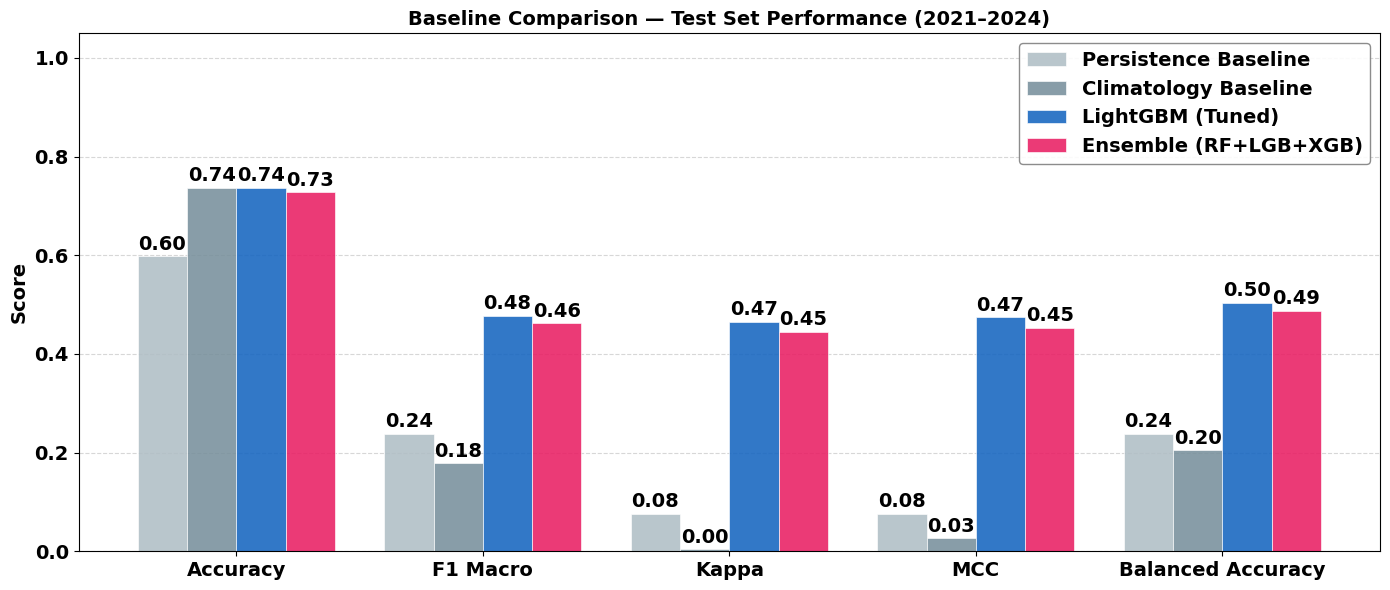

Saved: baseline_comparison_bar.png


In [17]:
# ------------------------------------------------------------
# Step 6: Visualization — Grouped Bar Chart
# ------------------------------------------------------------
metrics_cols = ['Accuracy', 'F1 Macro', 'Kappa',
                'MCC', 'Balanced Accuracy']

x = np.arange(len(metrics_cols))
bar_width = 0.2

colors = ['#B0BEC5', '#78909C', '#1565C0', '#E91E63']
model_list = results.index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(model_list, colors)):
    vals = [results.loc[model, m] for m in metrics_cols]

    bars = ax.bar(
        x + i * bar_width,
        vals,
        bar_width,
        label=model,
        color=color,
        alpha=0.88,
        edgecolor='white',
        linewidth=0.5
    )

    # Values above bars
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}',
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'
        )

# X-axis ticks
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(
    metrics_cols,
    fontsize=14,
    fontweight='bold'
)

# Y-axis ticks
ax.tick_params(
    axis='y',
    labelsize=14
)

# Make y tick labels bold
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Axis labels
ax.set_ylabel(
    'Score',
    fontsize=14,
    fontweight='bold'
)

# Title
ax.set_title(
    'Baseline Comparison — Test Set Performance (2021–2024)',
    fontsize=14,
    fontweight='bold'
)

# Legend
legend = ax.legend(
    fontsize=14,
    loc='upper right',
    framealpha=0.9,
    edgecolor='gray'
)

for text in legend.get_texts():
    text.set_fontweight('bold')

ax.set_ylim(0, 1.05)

ax.yaxis.grid(
    True,
    linestyle='--',
    alpha=0.5
)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    r'Results/baseline_comparison_bar.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: baseline_comparison_bar.png")

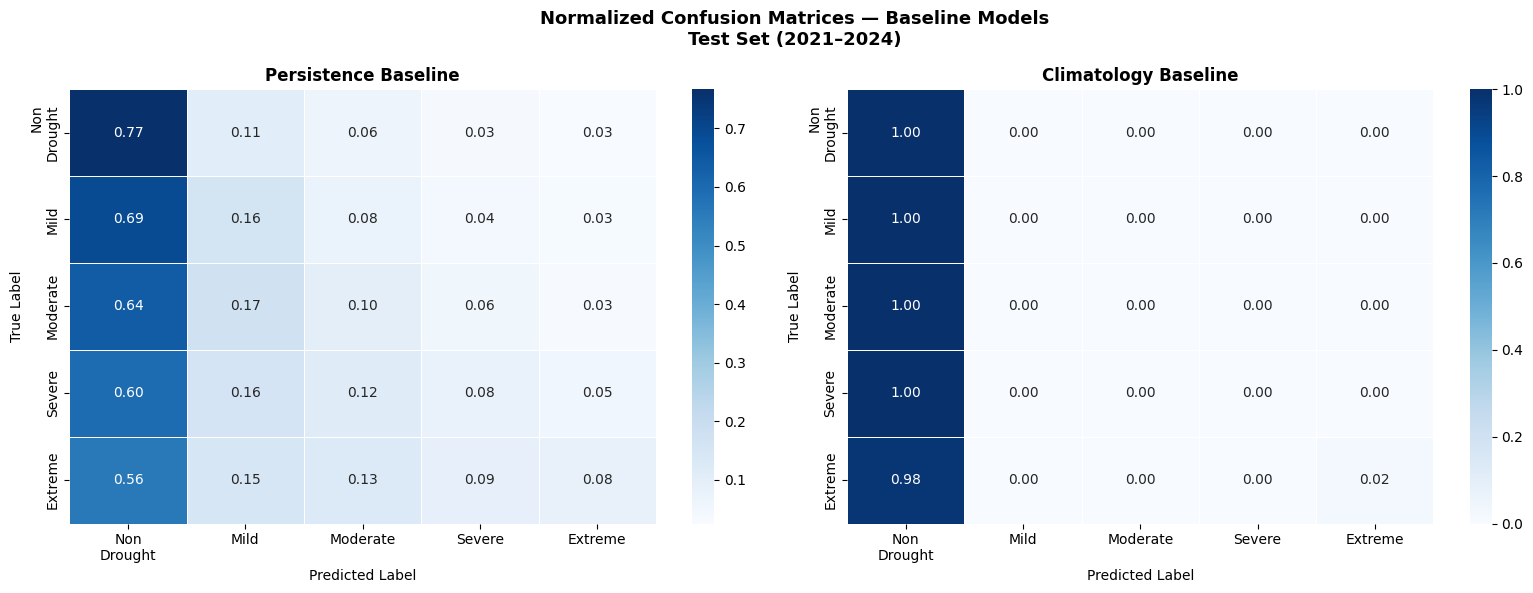

  Saved: baseline_confusion_matrices.png


In [14]:

# ------------------------------------------------------------
# Step 7: Confusion Matrices — Baselines side by side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_names = ['Non\nDrought', 'Mild', 'Moderate',
               'Severe', 'Extreme']

for ax, (y_pred, title) in zip(axes, [
    (y_pred_persist,   'Persistence Baseline'),
    (y_pred_clim_align,'Climatology Baseline'),
]):
    cm = confusion_matrix(y_true_aligned, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label',      fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.suptitle(
    'Normalized Confusion Matrices — Baseline Models\n'
    'Test Set (2021–2024)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(r'Results/baseline_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: baseline_confusion_matrices.png")


In [15]:

# ------------------------------------------------------------
# Step 8: Classification Reports — Baselines
# ------------------------------------------------------------
class_names_full = ['Non Drought', 'Mild Drought', 'Moderate Drought',
                    'Severe Drought', 'Extreme Drought']

print("\n--- Persistence Baseline Classification Report ---")
print(classification_report(y_true_aligned, y_pred_persist,
                             target_names=class_names_full,
                             zero_division=0))

print("\n--- Climatology Baseline Classification Report ---")
print(classification_report(y_true_aligned, y_pred_clim_align,
                             target_names=class_names_full,
                             zero_division=0))

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\n" + "="*55)
print("  Baseline Comparison Complete — Files Saved:")
print("="*55)
for f in ['baseline_comparison.csv',
          'baseline_comparison_bar.png',
          'baseline_confusion_matrices.png']:
    print(f"  Results/{f}")

print("\nManuscript use:")
print("  Table 1 → baseline_comparison.csv")
print("  Fig 4   → baseline_comparison_bar.png")



--- Persistence Baseline Classification Report ---
                  precision    recall  f1-score   support

     Non Drought       0.77      0.77      0.77    160863
    Mild Drought       0.16      0.16      0.16     26198
Moderate Drought       0.10      0.10      0.10     15926
  Severe Drought       0.08      0.08      0.08      8772
 Extreme Drought       0.08      0.08      0.08      6321

        accuracy                           0.60    218080
       macro avg       0.24      0.24      0.24    218080
    weighted avg       0.60      0.60      0.60    218080


--- Climatology Baseline Classification Report ---
                  precision    recall  f1-score   support

     Non Drought       0.74      1.00      0.85    160863
    Mild Drought       0.24      0.00      0.00     26198
Moderate Drought       0.00      0.00      0.00     15926
  Severe Drought       0.00      0.00      0.00      8772
 Extreme Drought       0.78      0.02      0.04      6321

        accuracy     